#**Normalidad y transfomación de datos**

En el análisis estadístico, uno de los supuestos más importantes es que los datos siguen una distribución normal (también conocida como distribución gaussiana). Este concepto es fundamental porque muchos métodos estadísticos clásicos, como la prueba t de Student, el ANOVA y la regresión lineal, requieren que los datos o los residuos del modelo tengan este tipo de distribución.
¿Qué es la normalidad?
Una variable tiene distribución normal cuando sus valores se distribuyen de manera simétrica alrededor de la media, formando una curva en forma de campana. En esta distribución:

La media, la mediana y la moda coinciden.
La mayoría de los valores se concentran cerca del centro.
Los valores extremos (muy altos o muy bajos) son poco frecuentes.

En el contexto médico, variables como la presión arterial, el peso o algunos parámetros bioquímicos pueden aproximarse a la normalidad en ciertas poblaciones, aunque no siempre ocurre así en la práctica clínica.
¿Por qué es importante la normalidad?
La normalidad es importante porque muchos procedimientos estadísticos suponen que los datos cumplen este requisito. Si los datos no son normales:

Los resultados de las pruebas pueden ser incorrectos o poco confiables.
Se pueden cometer errores en la interpretación clínica.
Las conclusiones podrían no reflejar la realidad de los pacientes.

Por ello, antes de realizar análisis estadísticos, es necesario verificar este supuesto.

In [ ]:
# Cargamos librerias
# Establecemos carpeta de trabajo
# Cargamos datos

install.packages("tidyverse")
install.packages("janitor")
library(tidyverse)
library(janitor)

datos <- read_csv("Data/datos_medicos.csv") %>%
  clean_names()

#**El histograma: visualización de la distribución de datos**

El histograma es una herramienta gráfica fundamental en estadística que permite observar cómo se distribuyen los valores de una variable. Es especialmente útil en el área médica para explorar datos antes de realizar análisis más complejos.
¿Qué es un histograma?
Un histograma es un tipo de gráfico de barras que representa la frecuencia de los datos dentro de intervalos llamados clases o bins. A diferencia de una gráfica de barras tradicional, en el histograma:

Los datos son continuos.
Las barras están pegadas entre sí (sin espacios).
Cada barra representa un rango de valores.

Por ejemplo, si se analizan niveles de glucosa en sangre, el histograma puede mostrar cuántos pacientes tienen valores entre 70–90 mg/dL, 90–110 mg/dL, etc.
¿Para qué sirve un histograma?
El histograma permite:

Visualizar la forma de la distribución de los datos.
Identificar si los datos son:

Simétricos (posible normalidad)
Asimétricos (sesgados a la derecha o izquierda)


Detectar valores atípicos (outliers).
Evaluar la dispersión de los datos.

En medicina, esto es crucial para entender el comportamiento de variables clínicas como presión arterial, niveles de colesterol o resultados de laboratorio.
Interpretación del histograma
Al observar un histograma, se deben tener en cuenta los siguientes aspectos:


Forma de la distribución:

Normal: forma de campana, simétrica.
Sesgada a la derecha: cola hacia valores altos (común en variables biológicas como triglicéridos).
Sesgada a la izquierda: cola hacia valores bajos.



Centro:

Dónde se concentra la mayor parte de los datos.



Variabilidad:

Qué tan dispersos están los valores.



Outliers:

Valores extremos que se alejan del resto.

In [ ]:
# ----------------------------------------------------------
# 1. Histograma
# ----------------------------------------------------------

ggplot(datos, aes(x = glucosa_mg_dl)) +
  geom_histogram(bins = 25, na.rm = TRUE) +
  labs(
    title = "Histograma de glucosa",
    x = "Glucosa (mg/dL)",
    y = "Frecuencia"
  ) +
  theme_minimal()


#**Gráfico Q-Q (Quantile-Quantile): evaluación de la normalidad**

El gráfico Q-Q (Quantile-Quantile) es una herramienta gráfica ampliamente utilizada en estadística para evaluar si un conjunto de datos sigue una distribución normal. Es considerado uno de los métodos más útiles y empleados en investigación médica debido a su claridad visual y facilidad de interpretación.
¿Qué es un gráfico Q-Q?
Un gráfico Q-Q compara los cuantiles de los datos observados con los cuantiles de una distribución teórica, generalmente la normal.

En el eje horizontal (X): cuantiles teóricos de una distribución normal.
En el eje vertical (Y): cuantiles de los datos observados.

Si los datos siguen una distribución normal, los puntos se alinearán aproximadamente sobre una línea recta.
¿Para qué sirve?
El gráfico Q-Q se utiliza principalmente para:

Evaluar si los datos siguen una distribución normal.
Detectar desviaciones de la normalidad (asimetría o colas pesadas).
Identificar valores atípicos (outliers).
Apoyar la decisión sobre qué pruebas estadísticas usar.

En medicina, es muy importante porque muchos análisis (como pruebas t, ANOVA o regresión) requieren normalidad de los datos o de los residuos.
¿Cómo se interpreta?
La interpretación del gráfico Q-Q es principalmente visual:
1. Datos normales

Los puntos se alinean siguiendo una línea recta.
Indica que los datos tienen una distribución aproximadamente normal.

2. Asimetría (sesgo)

Sesgo a la derecha: los puntos se desvían hacia arriba en la parte derecha.
Sesgo a la izquierda: los puntos se desvían hacia abajo en la parte izquierda.

3. Colas pesadas (outliers)

Los extremos se alejan de la línea recta.
Indica presencia de valores extremos.

4. Desviaciones sistemáticas

Curvaturas en forma de “S” indican que la distribución no es normal.


¿Por qué es uno de los más usados en medicina?
El gráfico Q-Q es muy popular en investigación médica por varias razones:

Es más informativo que un histograma para evaluar normalidad.
Permite detectar pequeñas desviaciones que otras pruebas no muestran.
Es fácil de interpretar visualmente, incluso con tamaños de muestra pequeños.
Complementa pruebas estadísticas como Shapiro-Wilk.

En estudios clínicos, epidemiológicos o experimentales, es común incluir gráficos Q-Q para validar los supuestos del análisis estadístico.
Comparación con otras herramientas
¿Por qué es uno de los más usados en medicina?
El gráfico Q-Q es muy popular en investigación médica por varias razones:

Es más informativo que un histograma para evaluar normalidad.
Permite detectar pequeñas desviaciones que otras pruebas no muestran.
Es fácil de interpretar visualmente, incluso con tamaños de muestra pequeños.
Complementa pruebas estadísticas como Shapiro-Wilk.

En estudios clínicos, epidemiológicos o experimentales, es común incluir gráficos Q-Q para validar los supuestos del análisis estadístico.



**Comparación con otras herramientas**

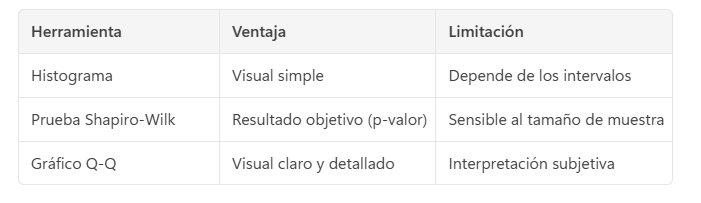
Por ello, lo ideal es usar el gráfico Q-Q junto con otras herramientas.

In [ ]:
# ----------------------------------------------------------
# 2. Gráfico Q-Q
# ----------------------------------------------------------

ggplot(datos, aes(sample = glucosa_mg_dl)) +
  stat_qq(na.rm = TRUE) +
  stat_qq_line(na.rm = TRUE) +
  labs(
    title = "Q-Q plot de glucosa",
    x = "Cuantiles teóricos",
    y = "Cuantiles observados"
  ) +
  theme_minimal()

#**Prueba de Shapiro-Wilk**

La prueba de Shapiro-Wilk es un método estadístico ampliamente utilizado para evaluar si un conjunto de datos sigue una distribución normal. Es especialmente popular en investigación médica debido a su buena sensibilidad, incluso con tamaños de muestra pequeños.
¿Qué es la prueba de Shapiro-Wilk?
La prueba de Shapiro-Wilk es una prueba de hipótesis que compara la distribución de los datos observados con una distribución normal teórica.
Se basa en dos hipótesis:

Hipótesis nula (H₀): los datos siguen una distribución normal.
Hipótesis alternativa (H₁): los datos no siguen una distribución normal.

El resultado principal de la prueba es un valor p (p-value), que permite tomar una decisión estadística.
¿Para qué sirve?
La prueba de Shapiro-Wilk se utiliza para:

Evaluar el supuesto de normalidad antes de aplicar pruebas estadísticas.
Decidir si usar métodos paramétricos (como t de Student) o no paramétricos (como Mann-Whitney).
Validar modelos estadísticos, especialmente en el análisis de residuos.

En medicina, esto es clave para asegurar que los análisis sean válidos y clínicamente confiables.
¿Cómo se interpreta?
La interpretación del valor p es sencilla:


p > 0.05:

No se rechaza la hipótesis nula.
Los datos pueden considerarse normales.



p ≤ 0.05:

Se rechaza la hipótesis nula.
Los datos no siguen una distribución normal.



Ejemplo:

p = 0.23 → distribución compatible con la normalidad.
p = 0.01 → evidencia de que los datos no son normales.

**Ventajas**

Muy potente para detectar desviaciones de la normalidad.
Funciona bien con muestras pequeñas (común en estudios clínicos).
Fácil de usar e interpretar.

**Limitaciones**

En muestras grandes, puede detectar desviaciones pequeñas que no son clínicamente relevantes.
No indica el tipo de desviación (asimetría, outliers, etc.).
Debe complementarse con métodos gráficos como:

Histograma
Gráfico Q-Q



**Aplicación en medicina**
En estudios médicos, la prueba de Shapiro-Wilk se utiliza frecuentemente para:

Analizar variables como glucosa, colesterol o presión arterial.
Evaluar datos antes de comparar grupos de pacientes.
Validar supuestos en ensayos clínicos o estudios observacionales.

Por ejemplo, antes de comparar la media de glucosa entre pacientes diabéticos y no diabéticos, es recomendable verificar si los datos son normales para elegir la prueba adecuada.
Recomendación práctica
La mejor práctica en análisis de datos es:

Evaluar la normalidad gráficamente (histograma, Q-Q).
Confirmar con la prueba de Shapiro-Wilk.
Decidir el tipo de análisis estadístico.


In [ ]:
shapiro.test(datos$glucosa_mg_dl)

#Salida típica:
#Shapiro-Wilk normality test
#data:  datos
#W = 0.97, p-value = 0.85

#W: estadístico de la prueba.
#p-value: valor clave para la interpretación.

#**Función para revisar la normalidad**

In [ ]:
revisar_normalidad <- function(data, variable) {
  x <- data[[variable]]
  x <- x[!is.na(x)]

  cat("\nVariable:", variable, "\n")
  cat("n =", length(x), "\n")
  cat("Media =", mean(x), "\n")
  cat("Mediana =", median(x), "\n")
  cat("DE =", sd(x), "\n\n")

  print(shapiro.test(x))

  p1 <- ggplot(data, aes(x = .data[[variable]])) +
    geom_histogram(bins = 25, na.rm = TRUE) +
    labs(title = paste("Histograma de", variable), x = variable, y = "Frecuencia") +
    theme_minimal()

  p2 <- ggplot(data, aes(sample = .data[[variable]])) +
    stat_qq(na.rm = TRUE) +
    stat_qq_line(na.rm = TRUE) +
    labs(title = paste("Q-Q plot de", variable), x = "Teórico", y = "Observado") +
    theme_minimal()

  print(p1)
  print(p2)
}

revisar_normalidad(datos, "glucosa_mg_dl")
revisar_normalidad(datos, "dias_estancia")
revisar_normalidad(datos, "colesterol_mg_dl")

#**¿Qué hacer si mis datos no son normales?**

Cuando los datos no siguen una distribución normal, una estrategia común es aplicar una transformación matemática para aproximarlos a la normalidad.
¿Por qué transformar los datos?
Las transformaciones ayudan a:

Reducir la asimetría (sesgo) de la distribución.
Disminuir la influencia de valores extremos.
Cumplir los supuestos de los análisis estadísticos.

Esto es especialmente útil en medicina, donde variables como niveles hormonales, concentraciones de glucosa o marcadores inflamatorios suelen estar sesgadas (generalmente hacia la derecha).
Tipos comunes de transformaciones


**Logarítmica:**
Se usa cuando los datos están muy sesgados a la derecha.
Ejemplo en R:
> log_datos <- log(datos)


**Raíz cuadrada:**
Útil para datos de conteo o con variabilidad moderada.
Ejemplo en R:
> sqrt_datos <- sqrt(datos)

**Inversa**
Se emplea en casos de alta dispersión.
Ejemplo en R:
> inv_datos <- 1/datos

**Box-Cox:**
Método más general que encuentra la mejor transformación automáticamente.

Consideraciones importantes

Después de transformar los datos, es necesario volver a evaluar la normalidad.
La interpretación clínica debe hacerse con cuidado, ya que los datos transformados no están en la escala original.
En algunos casos, es preferible utilizar métodos no paramétricos (como la prueba de Mann-Whitney o Kruskal-Wallis) en lugar de transformar los datos.


In [20]:
# Logaritmnica
datos$glucosa_log <- log(datos$glucosa_mg_dl)

#Si hay valores 0 (especialmente en días), usa:
#datos$dias_log <- log(datos$dias_estancia + 1)


In [21]:
# Raíz cuadrada
datos$glucosa_sqrt <- sqrt(datos$glucosa_mg_dl)


In [22]:
# Inversa
datos$glucosa_inv <- 1 / datos$glucosa_mg_dl

#**Verificar si funciono**

In [ ]:
#Histograma
hist(datos$glucosa_mg_dl)
hist(datos$glucosa_log)

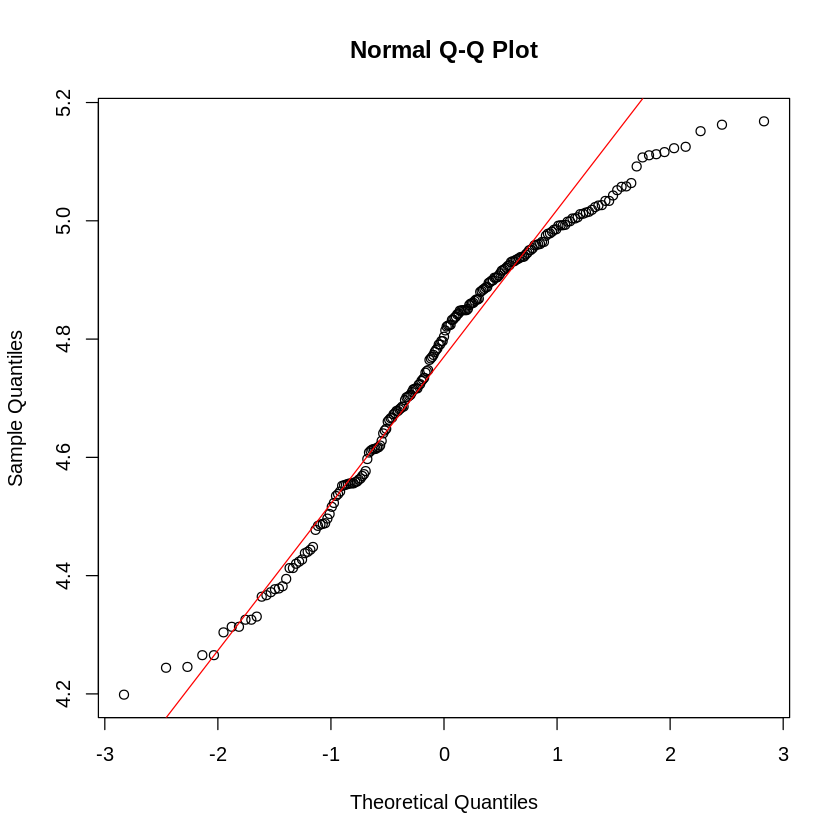

In [26]:
#Gráfico Q-Q
qqnorm(datos$glucosa_log)
qqline(datos$glucosa_log, col="red")

In [ ]:
# Shapiro-Wilk

shapiro.test(datos$glucosa_log)

#**Ejercicios**

**Ejercicio 1:**
Evaluar normalidad de imc.

**Ejercicio 2:**
 Evaluar normalidad de cambio_hb = hb_post - hb_pre.

**Ejercicio 3:**
Decidir si dias_estancia debería resumirse con media ± DE
 o con mediana [Q1, Q3].
